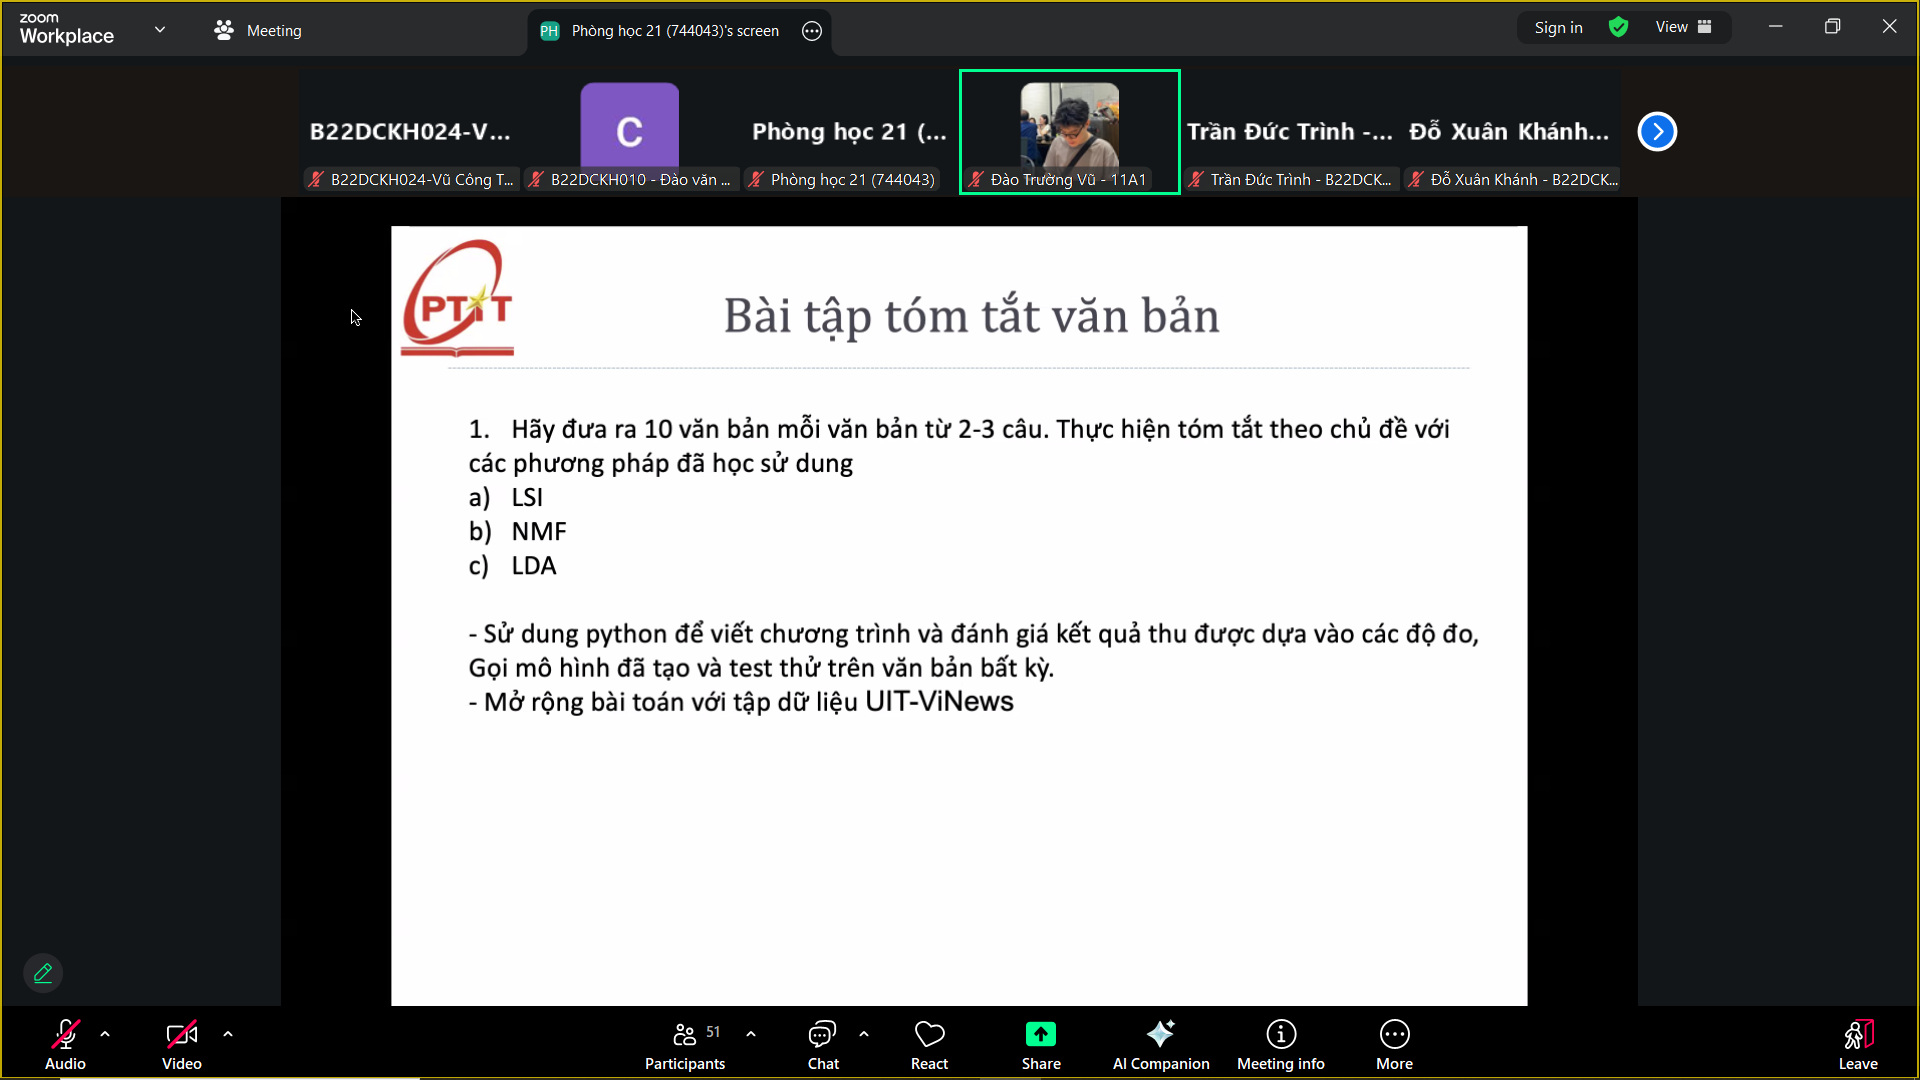

In [ ]:
# %%capture
!pip install gensim
!pip install pyvi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 11.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
openc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.1 MB/s eta 0:00:00


KeyboardInterrupt: 

In [ ]:
# %%capture
!pip install --upgrade gensim

In [ ]:
import nltk
import re
nltk.download('stopwords')
from gensim import corpora
from gensim.models import LsiModel
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Nmf
from gensim.models import ldamodel
import requests
from pyvi import ViTokenizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#Xóa từ dừng
stopwords_url = 'https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/refs/heads/master/vietnamese-stopwords.txt'

response = requests.get(stopwords_url)
stopwords = set(response.text.splitlines())

In [ ]:
data = [
    "Hôm nay trời nắng đẹp, tôi quyết định đi dạo công viên. Không khí trong lành và mát mẻ khiến tôi cảm thấy thư giãn hơn.",
    "Tôi vừa hoàn thành một cuốn sách thú vị về lịch sử Việt Nam. Những câu chuyện về các nhân vật lịch sử đã giúp tôi hiểu rõ hơn về văn hóa dân tộc.",
    "Cuối tuần này, gia đình tôi sẽ tổ chức một bữa tiệc nhỏ. Chúng tôi sẽ cùng nhau nấu ăn và chia sẻ những kỷ niệm đẹp.",
    "Tôi rất thích nghe nhạc vào buổi tối. Âm nhạc giúp tôi thư giãn và tạo cảm hứng cho những ý tưởng mới.",
    "Học tiếng Anh là một thử thách nhưng cũng rất thú vị. Tôi thường xem phim và nghe nhạc để cải thiện kỹ năng nghe của mình.",
    "Mỗi sáng, tôi thường tập thể dục để giữ sức khỏe. Việc này không chỉ giúp tôi khỏe mạnh mà còn tạo năng lượng cho cả ngày.",
    "Tôi thích khám phá những món ăn mới. Mỗi lần thử một món ăn mới, tôi lại cảm thấy như đang trải nghiệm một cuộc phiêu lưu.",
    "Việc đọc sách giúp tôi mở mang kiến thức và cải thiện khả năng tư duy. Tôi thường dành thời gian mỗi ngày để đọc ít nhất một chương sách.",
    "Tôi rất yêu thiên nhiên và thường đi leo núi vào cuối tuần. Cảm giác chinh phục đỉnh núi mang lại cho tôi niềm vui và sự tự hào.",
    "Công nghệ ngày càng phát triển, ảnh hưởng đến mọi lĩnh vực trong cuộc sống. Tôi luôn cố gắng cập nhật những xu hướng mới để không bị lạc hậu."
]


In [ ]:
import requests
from pyvi import ViTokenizer

def preprocess_data(doc_set):
    """
    Input  : docuemnt list and a set of stopwords
    Purpose: preprocess text (tokenize, removing stopwords, and stemming)
    Output : preprocessed text
    """
    # list for tokenized documents in loop
    texts = []
    punctuation = [
      ".",  # Period
      ",",  # Comma
      "!",  # Exclamation mark
      "?",  # Question mark
      ":",  # Colon
      ";",  # Semicolon
      "'",  # Apostrophe
      '"',  # Quotation mark
      "-",  # Hyphen
      "_",  # Underscore
      "(",  # Left parenthesis
      ")",  # Right parenthesis
      "[",  # Left bracket
      "]",  # Right bracket
      "{",  # Left brace
      "}",  # Right brace
      "<",  # Less than
      ">",  # Greater than
      "/",  # Forward slash
      "\\", # Backslash
      "|",  # Vertical bar
      "~",  # Tilde
      "`",  # Grave accent
  ]

    # loop through document list
    for i in doc_set:
        # clean and tokenize document string
        raw = i.lower()
        text = re.sub(r'[^a-zàáạảãăắằặẳẵâấầậẩẫèéẹẻẽêếềệểễìíịỉĩòóọỏõôốồộổỗơớờợởỡùúụủũưứừựửữýỳỵỷỹđ\s]', '', raw)
        tokens = ViTokenizer.tokenize(raw).split()
        tokens = [x.replace('_', ' ') for x in tokens]
        # remove stop words from tokens
        processed_tokens = [
            token
            for token in tokens
            if token.replace('_', ' ') not in stopwords
        ]
        # remove stop words from tokens
        stopped_tokens = [x for x in tokens if x not in stopwords]
        stopped_tokens = [x for x in stopped_tokens if x not in punctuation]
        texts.append(stopped_tokens)
    return texts

In [ ]:
def prepare_corpus(doc_clean):
    """
    Input  : clean document
    Purpose: create term dictionary of our courpus and Converting list of documents (corpus) into Document Term Matrix
    Output : term dictionary and Document Term Matrix
    """
    # Creating the term dictionary of our courpus, where every unique term is assigned an index. dictionary = corpora.Dictionary(doc_clean)
    dictionary = corpora.Dictionary(doc_clean)
    # Converting list of documents (corpus) into Document Term Matrix using dictionary prepared above.
    doc_term_matrix = [dictionary.doc2bow(doc) for doc in doc_clean]
    # generate LDA model
    return dictionary,doc_term_matrix


In [ ]:
def create_gensim_lsa_model(doc_clean,number_of_topics,words):
    """
    Input  : clean document, number of topics and number of words associated with each topic
    Purpose: create LSA model using gensim
    Output : return LSA model
    """
    dictionary,doc_term_matrix=prepare_corpus(doc_clean)
    # generate LSA model
    lsamodel = LsiModel(doc_term_matrix, num_topics=number_of_topics, id2word = dictionary)  # train model
    print(lsamodel.print_topics(num_topics=number_of_topics, num_words=words))
    return lsamodel


In [ ]:
def compute_coherence_values(dictionary, doc_term_matrix, doc_clean, stop, start=2, step=3):
    """
    Input   : dictionary : Gensim dictionary
              corpus : Gensim corpus
              texts : List of input texts
              stop : Max num of topics
    purpose : Compute c_v coherence for various number of topics
    Output  : model_list : List of LSA topic models
              coherence_values : Coherence values corresponding to the LDA model with respective number of topics
    """
    coherence_values = []
    model_list = []
    for num_topics in range(start, stop, step):
        # generate LSA model
        model = LsiModel(doc_term_matrix, num_topics=num_topics, id2word = dictionary)  # train model
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=doc_clean, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())
    return model_list, coherence_values

In [ ]:
def plot_graph(doc_clean,start, stop, step):
    dictionary,doc_term_matrix=prepare_corpus(doc_clean)
    model_list, coherence_values = compute_coherence_values(dictionary, doc_term_matrix,doc_clean,
                                                            stop, start, step)
    # Show graph
    x = range(start, stop, step)
    plt.plot(x, coherence_values)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence score")
    plt.legend(("coherence_values"), loc='best')
    plt.show()

In [ ]:
start,stop,step=2,12,1
number_of_topics = 3

In [ ]:
clean_text = preprocess_data(data)
plot_graph(clean_text,start,stop,step)

In [ ]:
words = 10
number_of_topics = 3

In [ ]:
model=create_gensim_lsa_model(clean_text,number_of_topics,words)

In [ ]:
result = model.print_topics(num_topics=number_of_topics, num_words=words)
for topic_id, topic_words in result:
  print(f"Topic {topic_id}: {topic_words}")

In [ ]:
def extract_words_from_topics(topics_string):
    """
    Extracts words from the string representation of topics.
    """
    words = []
    matches = re.findall(r'"(.*?)"', topics_string)
    words.extend(matches)
    return words
all_words = []
for topic_id, topic_words in result:
    words_in_topic = extract_words_from_topics(topic_words)
    print(f"Words in Topic {topic_id}: {words_in_topic}")
    all_words.extend(words_in_topic)

In [ ]:
dictionary,doc_term_matrix=prepare_corpus(clean_text)
coherencemodel = CoherenceModel(model=model, texts=clean_text, dictionary=dictionary, coherence='c_v')
coherencemodel2 = CoherenceModel(model=model, texts=clean_text, dictionary=dictionary, coherence='c_uci')
coherencemodel3 = CoherenceModel(model=model, texts=clean_text, dictionary=dictionary, coherence='c_npmi')

In [ ]:
coherence = coherencemodel.get_coherence()
coherence_uci = coherencemodel2.get_coherence()
coherence_npmi = coherencemodel3.get_coherence()
print(coherence, coherence_uci, coherence_npmi)

In [ ]:
# predict
test_data = ["Đọc sách rất tốt. Nó giúp chúng ta hiểu và cải thiện tư duy. Hãy giữ thói quen đọc sách"]


In [ ]:
# Preprocess the test data
clean_test_text = preprocess_data(test_data)
print("Preprocessed test data:", clean_test_text)

In [ ]:
# Prepare the test data corpus for prediction
test_dictionary = corpora.Dictionary(clean_test_text)
test_doc_term_matrix = [test_dictionary.doc2bow(doc) for doc in clean_test_text]

# Predict topics using the LSA model
for i, doc in enumerate(test_doc_term_matrix):
    topic_distribution = model[doc] # Use the trained LSA model (named 'model')
    print(f"Topic distribution for document {i}: {topic_distribution}")

# NMF


In [ ]:
nmf = Nmf(doc_term_matrix, num_topics=number_of_topics, id2word=dictionary)


In [ ]:
result_nmf = nmf.print_topics(num_topics=number_of_topics, num_words=words)
for topic_id, topic_words in result_nmf:
  print(f"Topic {topic_id}: {topic_words}")

In [ ]:
for topic_id, topic_words in result_nmf:
    words_in_topic = extract_words_from_topics(topic_words)
    print(f"Words in Topic {topic_id}: {words_in_topic}")

In [ ]:
# coherence
coherence_model_nmf = CoherenceModel(model=nmf, texts=clean_text, dictionary=dictionary, coherence='c_v')
coherence_model_nmf1 = CoherenceModel(model=nmf, texts=clean_text, dictionary=dictionary, coherence='c_uci')
coherence_model_nmf2 = CoherenceModel(model=nmf, texts=clean_text, dictionary=dictionary, coherence='c_npmi')
coherence_nmf = coherence_model_nmf.get_coherence()
coherence_nmf_uci = coherence_model_nmf1.get_coherence()
coherence_nmf_npmi = coherence_model_nmf2.get_coherence()
print(coherence_nmf, coherence_nmf_uci, coherence_nmf_npmi)

In [ ]:
# predict
for i, doc in enumerate(test_doc_term_matrix):
    topic_distribution = nmf[doc] # Use the trained LSA model (named 'model')
    print(f"Topic distribution for document {i}: {topic_distribution}")

# LDA

In [ ]:
lda = ldamodel.LdaModel(doc_term_matrix, num_topics=number_of_topics, id2word = dictionary, passes=50)

In [ ]:
result_lda = lda.print_topics(num_topics=number_of_topics, num_words=words)
for topic_id, topic_words in result_lda:
  print(f"Topic {topic_id}: {topic_words}")

In [ ]:
for topic_id, topic_words in result_lda:
    words_in_topic = extract_words_from_topics(topic_words)
    print(f"Words in Topic {topic_id}: {words_in_topic}")

In [ ]:
# coherence
coherence_model_lda = CoherenceModel(model=lda, texts=clean_text, dictionary=dictionary, coherence='c_v')
coherence_model_lda1 = CoherenceModel(model=lda, texts=clean_text, dictionary=dictionary, coherence='c_uci')
coherence_model_lda2 = CoherenceModel(model=lda, texts=clean_text, dictionary=dictionary, coherence='c_npmi')
coherence_lda = coherence_model_lda.get_coherence()
coherence_lda1_uci = coherence_model_lda1.get_coherence()
coherence_lda2_npmi = coherence_model_lda2.get_coherence()
print(coherence_lda, coherence_lda1_uci, coherence_lda2_npmi)

In [ ]:
# predict
for i, doc in enumerate(test_doc_term_matrix):
    topic_distribution = lda[doc] # Use the trained LSA model (named 'model')
    print(f"Topic distribution for document {i}: {topic_distribution}")

# UIT ViOnNews
https://github.com/kh4nh12/UIT-ViON-Dataset/blob/main/data.zip

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/PTIT-Projects/nlp-learning/refs/heads/main/week8/data/UIT-ViON_train.csv')
df.head()

In [ ]:
data = df['title'].to_list()

In [ ]:
new_data = [x.replace('_', ' ') for x in data]

In [ ]:
clean_text = preprocess_data(new_data)

In [ ]:
model=create_gensim_lsa_model(clean_text,number_of_topics,words)

In [ ]:
result = model.print_topics(num_topics=number_of_topics, num_words=words)
for topic_id, topic_words in result:
  print(f"Topic {topic_id}: {topic_words}")

In [ ]:
dictionary,doc_term_matrix=prepare_corpus(clean_text)
coherencemodel = CoherenceModel(model=model, texts=clean_text, dictionary=dictionary, coherence='c_v')
coherencemodel2 = CoherenceModel(model=model, texts=clean_text, dictionary=dictionary, coherence='c_uci')
coherencemodel3 = CoherenceModel(model=model, texts=clean_text, dictionary=dictionary, coherence='c_npmi')
coherence = coherencemodel.get_coherence()
coherence_uci = coherencemodel2.get_coherence()
coherence_npmi = coherencemodel3.get_coherence()
print(coherence, coherence_uci, coherence_npmi)

In [ ]:
nmf = Nmf(doc_term_matrix, num_topics=number_of_topics, id2word=dictionary)
result_nmf = nmf.print_topics(num_topics=number_of_topics, num_words=words)
for topic_id, topic_words in result_nmf:
  print(f"Topic {topic_id}: {topic_words}")

In [ ]:
coherence_model_nmf = CoherenceModel(model=nmf, texts=clean_text, dictionary=dictionary, coherence='c_v')
coherence_model_nmf1 = CoherenceModel(model=nmf, texts=clean_text, dictionary=dictionary, coherence='c_uci')
coherence_model_nmf2 = CoherenceModel(model=nmf, texts=clean_text, dictionary=dictionary, coherence='c_npmi')
coherence_nmf = coherence_model_nmf.get_coherence()
coherence_nmf_uci = coherence_model_nmf1.get_coherence()
coherence_nmf_npmi = coherence_model_nmf2.get_coherence()
print(coherence_nmf, coherence_nmf_uci, coherence_nmf_npmi)

In [ ]:
# lda = ldamodel.LdaModel(doc_term_matrix, num_topics=number_of_topics, id2word = dictionary, passes=50)
# result_lda = lda.print_topics(num_topics=number_of_topics, num_words=words)
# for topic_id, topic_words in result_lda:
#   print(f"Topic {topic_id}: {topic_words}")

In [ ]:
# # coherence
# coherence_model_lda = CoherenceModel(model=lda, texts=clean_text, dictionary=dictionary, coherence='c_v')
# coherence_model_lda1 = CoherenceModel(model=lda, texts=clean_text, dictionary=dictionary, coherence='c_uci')
# coherence_model_lda2 = CoherenceModel(model=lda, texts=clean_text, dictionary=dictionary, coherence='c_npmi')
# coherence_lda = coherence_model_lda.get_coherence()
# coherence_lda1_uci = coherence_model_lda1.get_coherence()
# coherence_lda2_npmi = coherence_model_lda2.get_coherence()
# print(coherence_lda, coherence_lda1_uci, coherence_lda2_npmi)

In [ ]:
# Load the test set
df_test = pd.read_csv('https://raw.githubusercontent.com/PTIT-Projects/nlp-learning/refs/heads/main/week8/data/UIT-ViON_test.csv')
display(df_test.head())

In [ ]:
# Extract the titles from the test set
test_data = df_test['title'].to_list()

# Handle underscores in the test data
new_test_data = [x.replace('_', ' ') for x in test_data]

# Preprocess the test data
clean_test_text = preprocess_data(new_test_data)

In [ ]:
# Prepare the test data corpus for prediction
# Use the dictionary created from the training data
test_dictionary = dictionary # Use dictionary from training data

# Filter test data to only include words present in the training dictionary
filtered_clean_test_text = []
for doc in clean_test_text:
    filtered_doc = [word for word in doc if word in test_dictionary.token2id]
    filtered_clean_test_text.append(filtered_doc)


test_doc_term_matrix = [test_dictionary.doc2bow(doc) for doc in filtered_clean_test_text]

print("Test Document-Term Matrix (first document):", test_doc_term_matrix[0])

In [ ]:
# Predict topics using the NMF model on the test set
print("\nNMF Model Predictions:")
for i, doc in enumerate(test_doc_term_matrix):
    topic_distribution = nmf[doc] # Use the trained NMF model
    print(f"Document {i} Topic Distribution (NMF): {topic_distribution}")

In [ ]:
# # Predict topics using the LSA model on the test set
# print("LSA Model Predictions:")
# for i, doc in enumerate(test_doc_term_matrix):
#     topic_distribution = model[doc] # Use the trained LSA model
#     print(f"Document {i} Topic Distribution (LSA): {topic_distribution}")